In [53]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [54]:
class BmiState(TypedDict):
    
    weigth_kg:float
    heigth_m:float
    bmi:float
    category:str

In [55]:
def calculate_bmi(State:BmiState)-> BmiState:
    
    weigth = State['weigth_kg']
    heigth = State['heigth_m']
    bmi = weigth/(heigth**2)
    
    State['bmi']=round(bmi,2)
    return State

In [59]:
def label_bmi(State:BmiState)->BmiState:
    bmi = State['bmi']
    if bmi < 18.5:
        State["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        State["category"] = "Normal"
    elif 25 <= bmi < 30:
       State["category"] = "Overweight"
    else:
        State["category"] = "Obese"

    return State

In [61]:
graph = StateGraph(BmiState)

graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('labal_bmi',label_bmi)

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','labal_bmi')
graph.add_edge('labal_bmi',END)

workflow=graph.compile()

In [62]:
intail_state = {'weigth_kg':80,'heigth_m':1.73}
final_state=workflow.invoke(intail_state)

print(final_state)

{'weigth_kg': 80, 'heigth_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


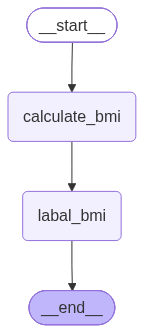

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())